<a href="https://colab.research.google.com/github/ghattamanenikevinjosh-ai/2520030213_ML/blob/main/Project/EDA%20ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import seaborn as sns

In [2]:
#https://www.kaggle.com/datasets/sonalshinde123/student-placement-dataset
from pandas import read_csv
df=read_csv("/content/player_performance_website_dataset_1000.csv")

In [3]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['MatchesPlayed', 'Goals', 'Assists', 'Shots', 'ShotsOnTarget', 'PassAccuracy', 'Tackles', 'Player_Performance_Score']
Categorical Features: ['Player_ID']


In [4]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [5]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                          MatchesPlayed     Goals   Assists     Shots  \
MatchesPlayed                  1.000000 -0.002227  0.000474 -0.051586   
Goals                         -0.002227  1.000000 -0.051236  0.560928   
Assists                        0.000474 -0.051236  1.000000 -0.030292   
Shots                         -0.051586  0.560928 -0.030292  1.000000   
ShotsOnTarget                 -0.048419  0.443440 -0.053905  0.781575   
PassAccuracy                  -0.004438 -0.043088 -0.044956 -0.056740   
Tackles                        0.043540  0.045800 -0.002018  0.034064   
Player_Performance_Score       0.447245  0.579903  0.315159  0.463248   

                          ShotsOnTarget  PassAccuracy   Tackles  \
MatchesPlayed                 -0.048419     -0.004438  0.043540   
Goals                          0.443440     -0.043088  0.045800   
Assists                       -0.053905     -0.044956 -0.002018   
Shots                          0.781575     -0

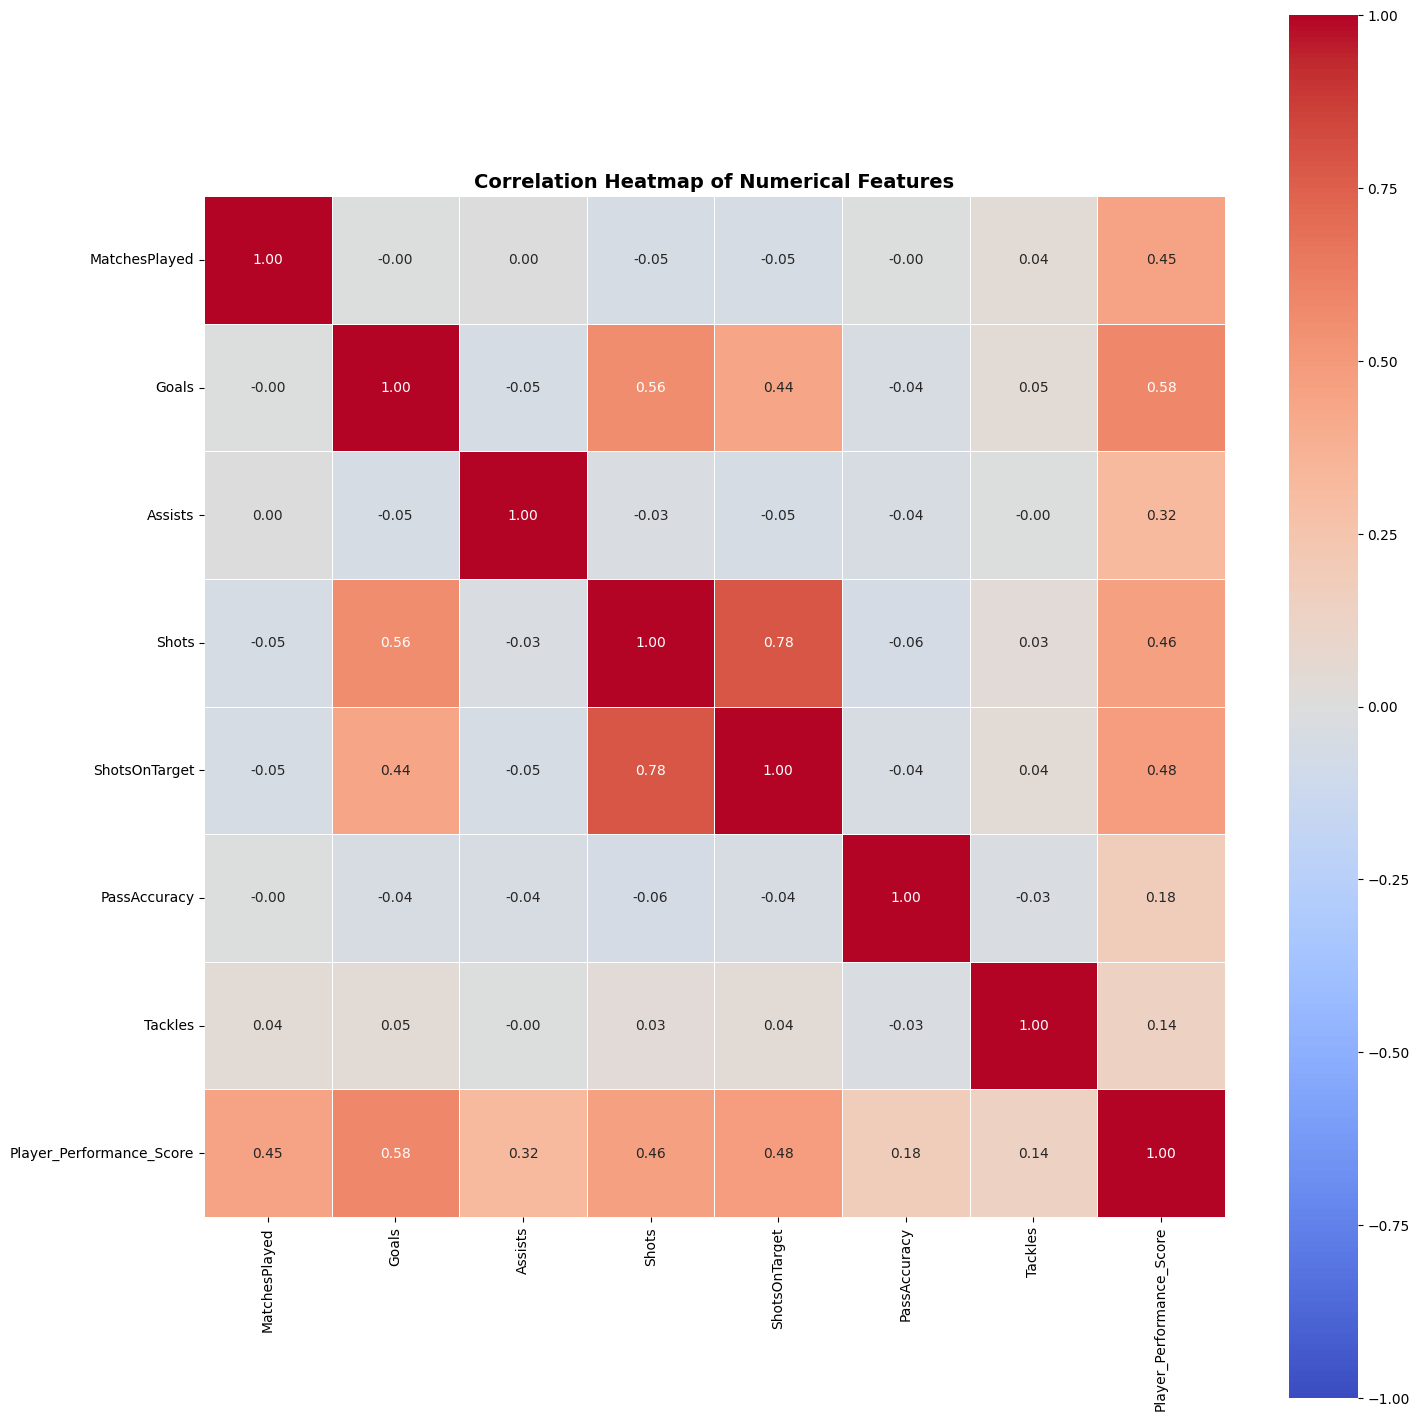

In [11]:
# Create Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns only
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(15,15))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:

# Export Heatmap
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


In [8]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs PlacementStatus
# -------------------------------------------------------------
target_col = "PlacementStatus"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()


        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")



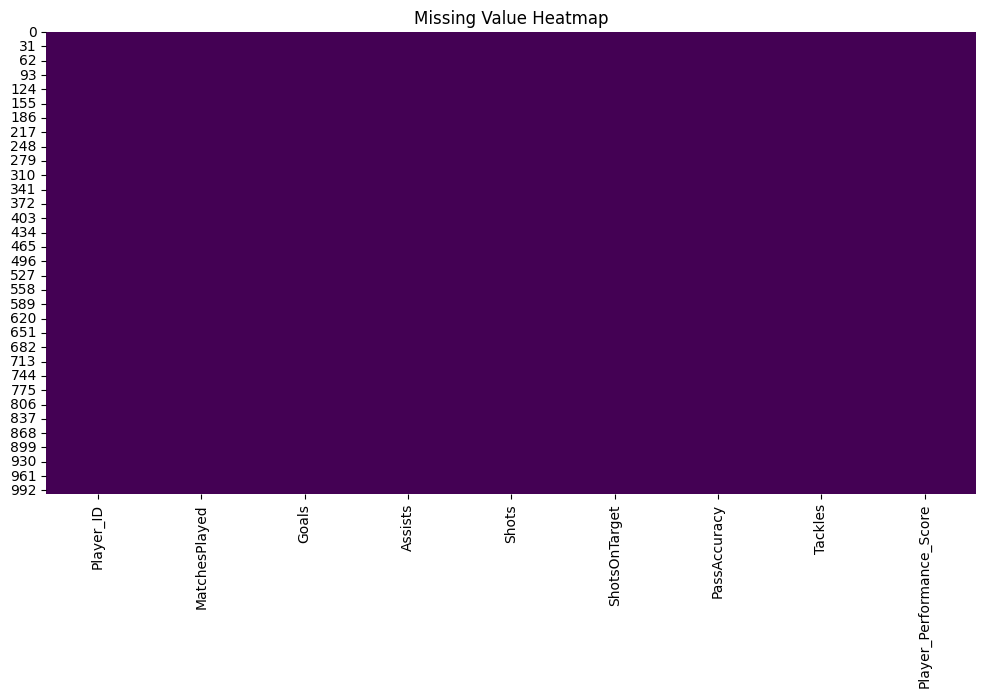

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig1 = plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

<Figure size 1500x800 with 0 Axes>

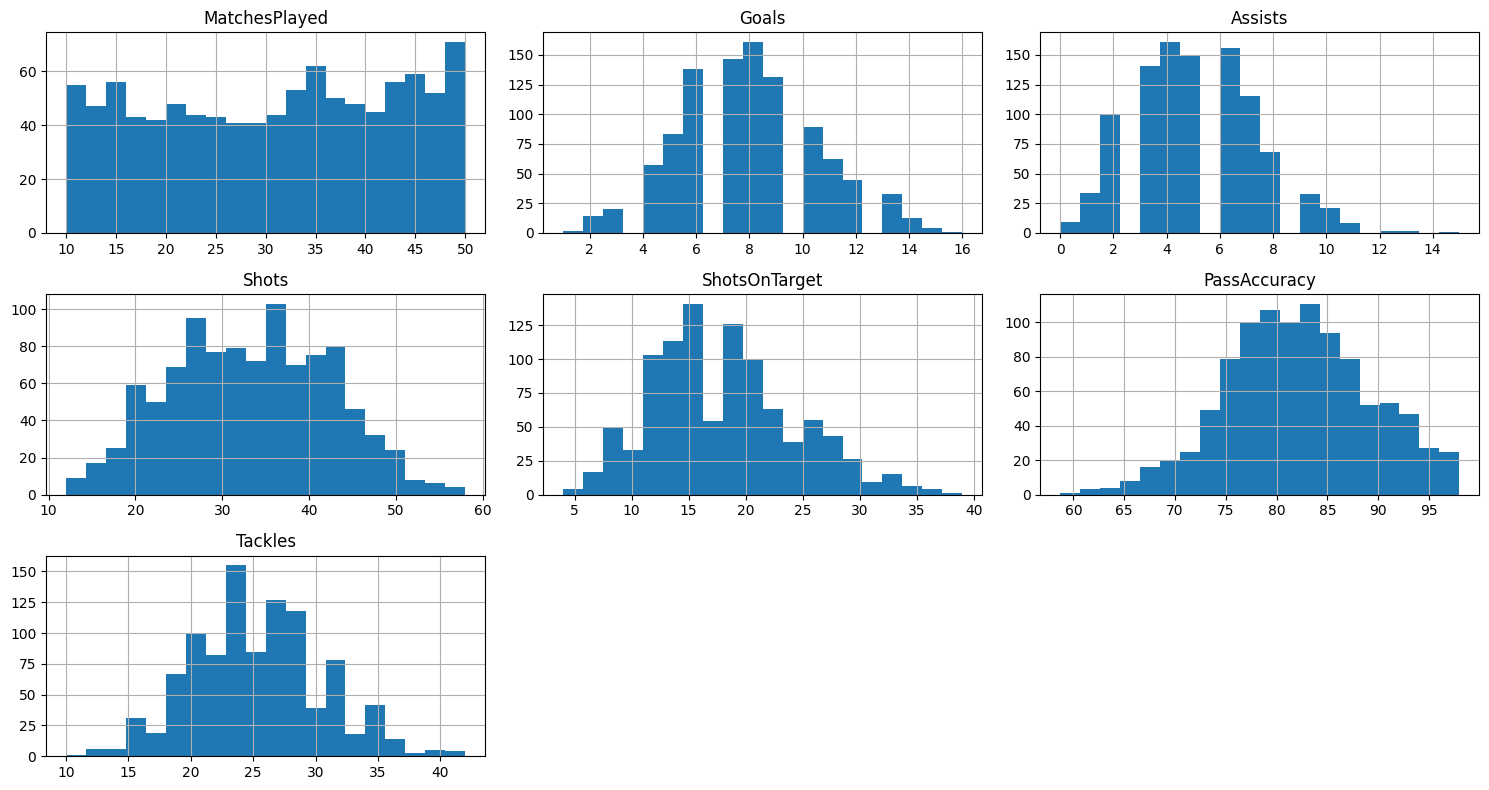

In [13]:
import matplotlib.pyplot as plt

features = [
    "MatchesPlayed",
    "Goals",
    "Assists",
    "Shots",
    "ShotsOnTarget",
    "PassAccuracy",
    "Tackles"
]

fig2 = plt.figure(figsize=(15,8))

df[features].hist(
    bins=20,
    figsize=(15,8)
)

plt.tight_layout()
plt.show()

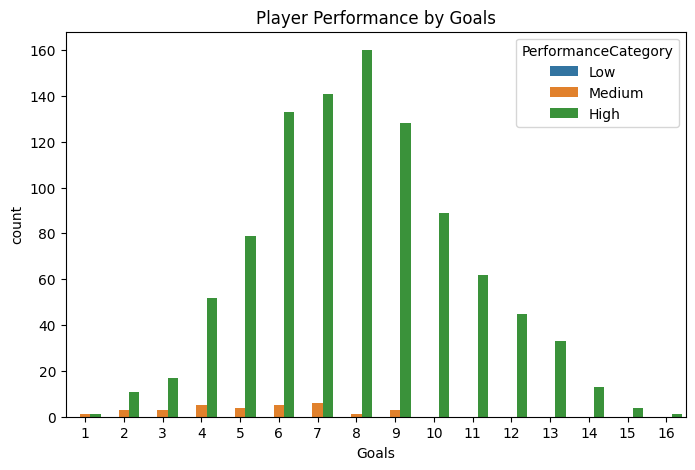

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df["PerformanceCategory"] = pd.cut(
    df["Player_Performance_Score"],
    bins=[0, 50, 70, 100],
    labels=["Low", "Medium", "High"]
)

# Player performance by goals

fig3 = plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Goals",
    hue="PerformanceCategory"
)

plt.title("Player Performance by Goals")

plt.show()

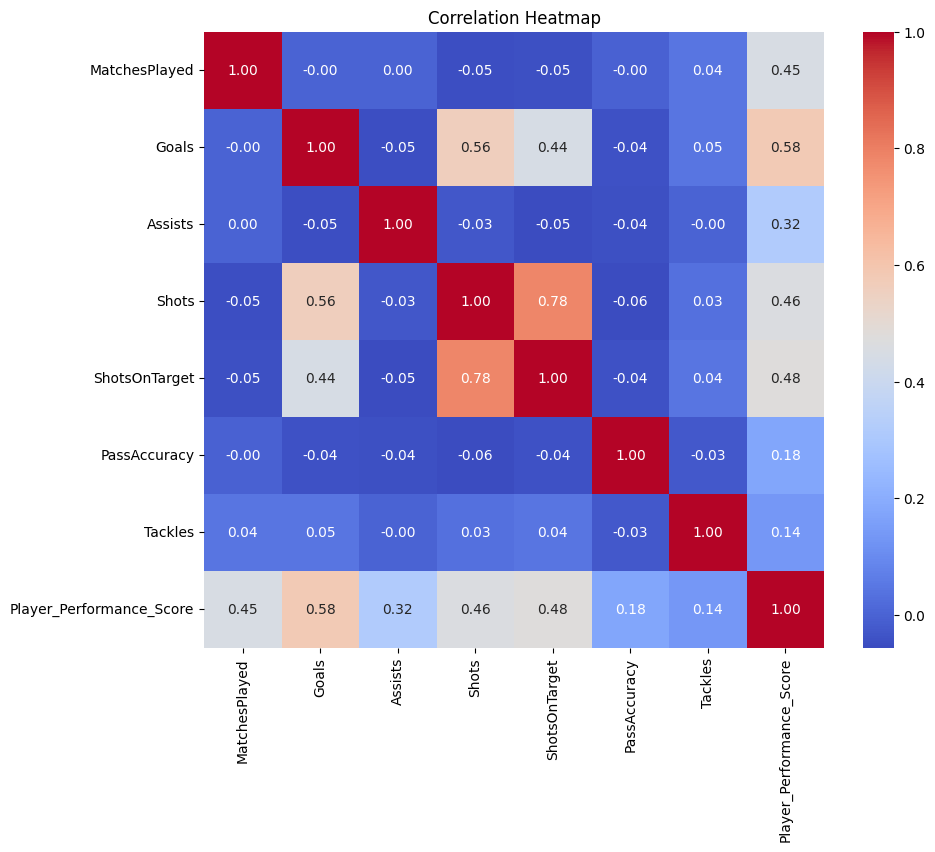

In [16]:
#Corelation Heatmap

fig5= plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

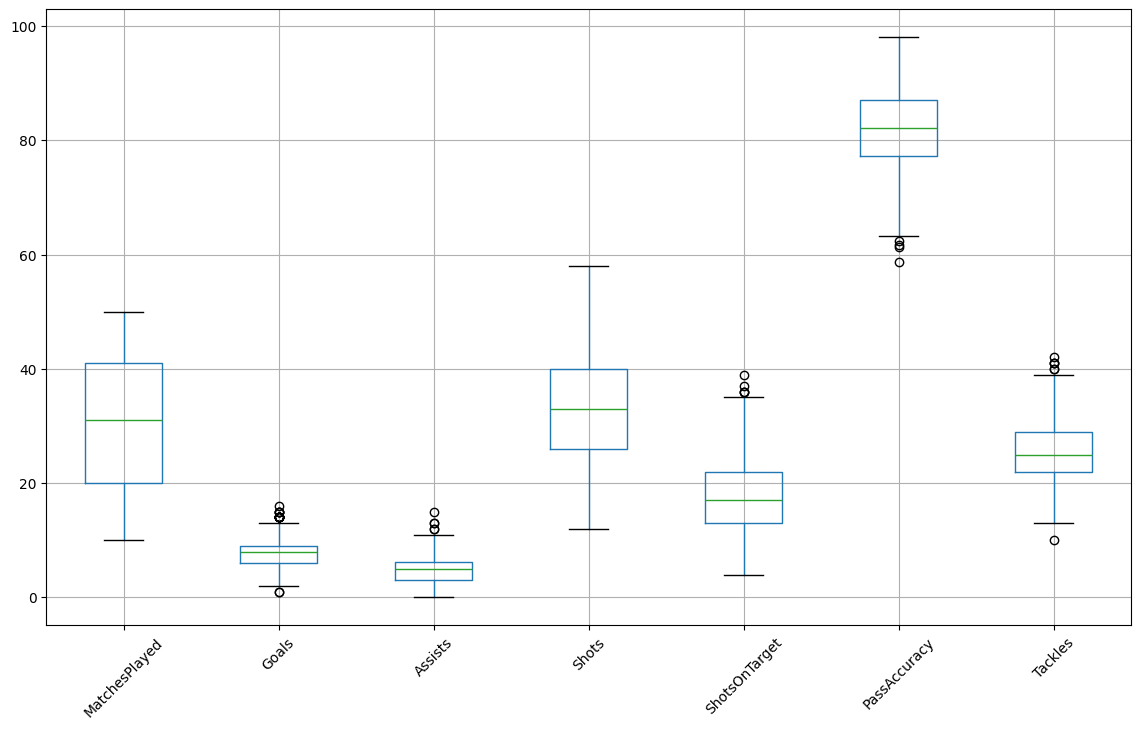

In [18]:
# Boxplots

numerical_columns = [
    "MatchesPlayed",
    "Goals",
    "Assists",
    "Shots",
    "ShotsOnTarget",
    "PassAccuracy",
    "Tackles"
]

fig6 = plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

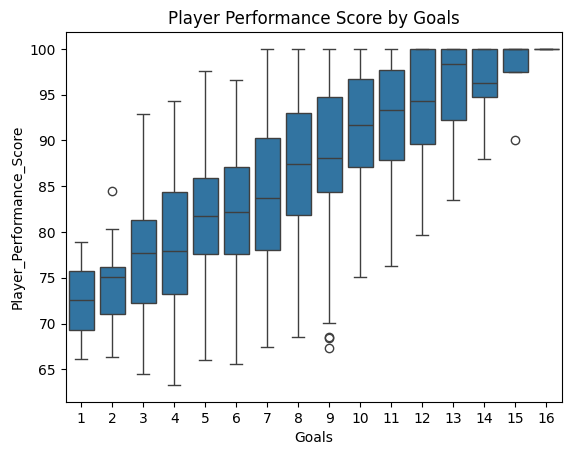

In [20]:
fig7 = sns.boxplot(
    x="Goals",
    y="Player_Performance_Score",
    data=df
)

plt.title("Player Performance Score by Goals")
plt.show()

In [21]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)


print("EDA Report saved successfully.")

EDA Report saved successfully.
